# Transfer Learning with MobileNetV2: Cats vs Dogs

This notebook introduces the core transfer-learning workflow using a pretrained MobileNetV2 backbone. It progresses from frozen feature extraction to partial fine-tuning with a reduced learning rate.

The workflow demonstrates how ImageNet features can be adapted to a smaller binary image-classification problem while controlling which pretrained layers are updated.


## Learning Objectives

- load a pretrained convolutional backbone without its original classifier,
- freeze pretrained features for initial feature extraction,
- add data augmentation and a new binary classification head,
- train the classifier while the backbone remains frozen,
- selectively unfreeze upper backbone layers,
- fine-tune with a smaller learning rate,
- compare training and validation behavior before and after fine-tuning.


## Imports and Utility Functions


In [12]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Rescaling,
    GlobalAveragePooling2D,
    Dropout,
    Dense,
)
from tensorflow.keras.losses import BinaryCrossentropy

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [13]:
def plot_results(history):
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4))

    ax[0].plot(history.history["accuracy"], label="train")
    ax[0].plot(history.history["val_accuracy"], label="validation")
    ax[0].set_title("Accuracy")
    ax[0].legend(loc="lower right")
    ax[0].grid(True)

    ax[1].plot(history.history["loss"], label="train")
    ax[1].plot(history.history["val_loss"], label="validation")
    ax[1].set_title("Loss")
    ax[1].legend(loc="upper right")
    ax[1].grid(True)

    plt.show()


def print_best_metrics(history_dict):
    metrics = [
        ("training accuracy", "accuracy", "max"),
        ("validation accuracy", "val_accuracy", "max"),
        ("training loss", "loss", "min"),
        ("validation loss", "val_loss", "min"),
    ]

    for label, key, mode in metrics:
        values = np.asarray(history_dict[key])

        if mode == "max":
            best_index = int(np.argmax(values))
            descriptor = "highest"
        else:
            best_index = int(np.argmin(values))
            descriptor = "lowest"

        print(
            f"The {descriptor} {label} was "
            f"{values[best_index]:.4f} in epoch {best_index + 1}"
        )
        print(f"The final {label} was {values[-1]:.4f}")


## Cats vs Dogs Dataset

The older filtered Cats vs Dogs archive used by the original TensorFlow tutorial can return HTTP 403 in some current Colab runtimes. This notebook therefore downloads the official Microsoft **Kaggle Cats and Dogs Dataset** and creates a reproducible smaller training/validation subset for the transfer-learning experiment.

The subset keeps the experiment computationally manageable while preserving the binary Cats vs Dogs task.


In [14]:
from pathlib import Path
import shutil
from PIL import Image

MICROSOFT_CATS_DOGS_URL = (
    "https://download.microsoft.com/download/3/e/1/"
    "3e1c3f21-ecdb-4869-8368-6deba77b919f/"
    "kagglecatsanddogs_5340.zip"
)

archive_path = Path(
    tf.keras.utils.get_file(
        fname="kagglecatsanddogs_5340.zip",
        origin=MICROSOFT_CATS_DOGS_URL,
        extract=True,
    )
)

CACHE_DIR = archive_path.parent

# Locate the extracted PetImages directory without assuming
# a version-specific Keras extraction path.
pet_dirs = [
    p for p in CACHE_DIR.rglob("PetImages")
    if p.is_dir()
]

if not pet_dirs:
    raise FileNotFoundError(
        f"Could not locate the extracted PetImages directory under {CACHE_DIR}."
    )

PET_DIR = pet_dirs[0]

print("Cats vs Dogs source directory:", PET_DIR)
print("Cat directory:", PET_DIR / "Cat")
print("Dog directory:", PET_DIR / "Dog")


Cats vs Dogs source directory: /root/.keras/datasets/kagglecatsanddogs_5340_extracted/PetImages
Cat directory: /root/.keras/datasets/kagglecatsanddogs_5340_extracted/PetImages/Cat
Dog directory: /root/.keras/datasets/kagglecatsanddogs_5340_extracted/PetImages/Dog


## Build a Reproducible Cats vs Dogs Subset

The Microsoft archive is larger than the older filtered tutorial dataset and contains some damaged image files. The preparation step validates image files first, then creates a balanced subset with:

- 1,000 cat + 1,000 dog training images
- 500 cat + 500 dog validation images

This matches the scale of the original filtered transfer-learning example while using a currently maintained official dataset source.


In [15]:
BATCH_SIZE = 64
IMG_SIZE = (160, 160)

PORTFOLIO_DATA_DIR = CACHE_DIR / "cats_and_dogs_portfolio"

TRAIN_PER_CLASS = 1000
VAL_PER_CLASS = 500
TOTAL_PER_CLASS = TRAIN_PER_CLASS + VAL_PER_CLASS


def collect_valid_images(source_dir, required_count):
    valid_files = []

    image_paths = []
    # Broaden the search for image extensions to include common JPEG and PNG variants, case-insensitive.
    for ext in [".jpg", ".JPG", ".jpeg", ".JPEG", ".png", ".PNG"]:
        image_paths.extend(source_dir.glob(f"*{ext}"))

    # Sort to ensure reproducibility
    sorted_image_paths = sorted(image_paths)

    # Report the number of candidate image files before validation.
    print(f"DEBUG: Found {len(sorted_image_paths)} potential image files (including PNG) in {source_dir}")

    for image_path in sorted_image_paths:
        try:
            if not image_path.is_file():
                continue
            # Skip 0-byte files, which are known to cause issues in this dataset
            if image_path.stat().st_size == 0:
                continue

            # First, try opening with PIL and verifying, as a quick check
            with Image.open(image_path) as image:
                image.verify()  # Check for integrity

            # Now, attempt to decode and preprocess with TensorFlow to ensure full compatibility.
            # This is the most direct way to prevent tf.keras.utils.image_dataset_from_directory errors.
            image_bytes = tf.io.read_file(str(image_path))
            decoded_image = tf.image.decode_image(image_bytes, channels=3)
            _ = tf.image.convert_image_dtype(decoded_image, tf.float32) # Ensure it can be converted
            _ = tf.image.resize(decoded_image, IMG_SIZE) # Ensure it can be resized

            valid_files.append(image_path)

            if len(valid_files) >= required_count:
                break

        except Exception:
            # Skip corrupted or unreadable image files that fail PIL or advanced TF checks.
            continue

    if len(valid_files) < required_count:
        raise RuntimeError(
            f"Only {len(valid_files)} valid images were found in {source_dir}; "
            f"{required_count} are required. Please check dataset integrity or reduce the required count."
        )

    return valid_files


def prepare_class_subset(class_name):
    source_dir = PET_DIR / class_name
    valid_files = collect_valid_images(
        source_dir,
        TOTAL_PER_CLASS,
    )

    train_files = valid_files[:TRAIN_PER_CLASS]
    val_files = valid_files[
        TRAIN_PER_CLASS:TRAIN_PER_CLASS + VAL_PER_CLASS
    ]

    destinations = {
        "train": train_files,
        "validation": val_files,
    }

    for split_name, files in destinations.items():
        target_dir = (
            PORTFOLIO_DATA_DIR
            / split_name
            / class_name.lower()
        )
        target_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        for image_path in files:
            target_path = target_dir / image_path.name

            if not target_path.exists():
                shutil.copy2(
                    image_path,
                    target_path,
                )

# Remove existing portfolio directory to ensure fresh dataset preparation with updated validation
if PORTFOLIO_DATA_DIR.exists():
    print(f"Removing existing {PORTFOLIO_DATA_DIR} to re-prepare dataset.")
    shutil.rmtree(PORTFOLIO_DATA_DIR)

if not (PORTFOLIO_DATA_DIR / "train").exists():
    prepare_class_subset("Cat")
    prepare_class_subset("Dog")

train_dir = PORTFOLIO_DATA_DIR / "train"
validation_dir = PORTFOLIO_DATA_DIR / "validation"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    seed=42,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    shuffle=True,
    seed=42,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
)

class_names = train_ds.class_names

print("Classes:", class_names)
print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())

Removing existing /root/.keras/datasets/cats_and_dogs_portfolio to re-prepare dataset.
DEBUG: Found 12500 potential image files (including PNG) in /root/.keras/datasets/kagglecatsanddogs_5340_extracted/PetImages/Cat
DEBUG: Found 12500 potential image files (including PNG) in /root/.keras/datasets/kagglecatsanddogs_5340_extracted/PetImages/Dog
Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Classes: ['cat', 'dog']
Training batches: 32
Validation batches: 16


## Load the Pretrained MobileNetV2 Backbone

`include_top=False` removes MobileNetV2's original ImageNet classifier and retains the convolutional feature extractor.


In [16]:
IMG_SHAPE = IMG_SIZE + (3,)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights="imagenet",
)

base_model.trainable = False

print("Number of layers in MobileNetV2:", len(base_model.layers))
base_model.summary()


Number of layers in MobileNetV2: 154


Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## Data Augmentation


In [17]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.2),
    ],
    name="data_augmentation",
)


## Feature Extraction Model

The pretrained backbone is frozen during the first stage. A new binary classification head is added after global average pooling.


In [18]:
inputs = Input(shape=IMG_SHAPE)

x = data_augmentation(inputs)
x = Rescaling(1.0 / 127.5, offset=-1)(x)

# training=False keeps MobileNetV2 batch-normalization layers
# in inference mode while using the pretrained feature extractor.
x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)

outputs = Dense(
    1,
    activation="sigmoid",
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="mobilenetv2_feature_extractor",
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=BinaryCrossentropy(),
    metrics=["accuracy"],
)

model.summary()


Model: "mobilenetv2_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Train the Frozen-Backbone Model


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.7640 - loss: 0.4704 - val_accuracy: 0.9590 - val_loss: 0.1588
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9255 - loss: 0.1979 - val_accuracy: 0.9650 - val_loss: 0.1075
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9325 - loss: 0.1659 - val_accuracy: 0.9700 - val_loss: 0.0943
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9400 - loss: 0.1480 - val_accuracy: 0.9700 - val_loss: 0.0882
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9480 - loss: 0.1320 - val_accuracy: 0.9700 - val_loss: 0.0826
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9445 - loss: 0.1345 - val_accuracy: 0.9710 - val_loss: 0.0796
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9540 - loss: 0.1198 - val_accuracy: 0.9740 - val_loss: 0.0782
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9510 - loss: 0.1271 - val_accuracy: 0.9740 - v

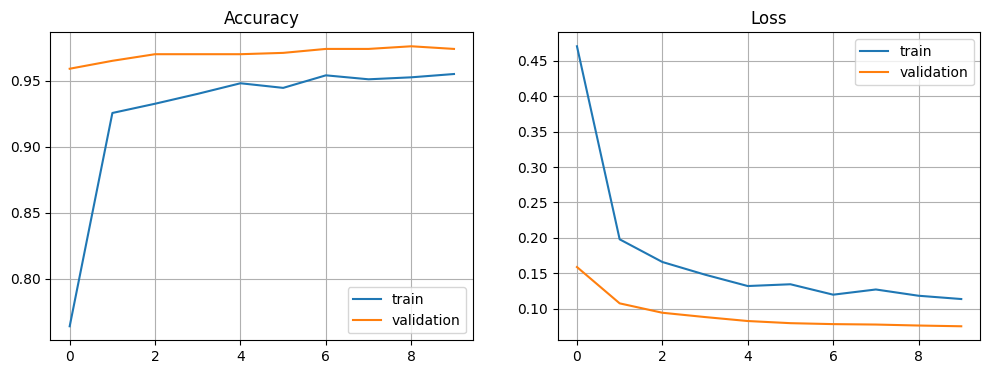

In [19]:
INITIAL_EPOCHS = 10

history_feature_extraction = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    verbose=1,
)

print_best_metrics(history_feature_extraction.history)
plot_results(history_feature_extraction)


## Partial Fine-Tuning

After the new classifier has learned from the frozen features, the upper part of MobileNetV2 is made trainable. Lower layers remain frozen because they tend to contain more general visual features.

Fine-tuning uses a smaller learning rate to avoid large updates to pretrained weights.


In [20]:
base_model.trainable = True

print("Number of layers in the base model:", len(base_model.layers))

start_fine_tune_at = 100

for layer in base_model.layers[:start_fine_tune_at]:
    layer.trainable = False

print(
    "Trainable backbone layers:",
    sum(layer.trainable for layer in base_model.layers),
)
print(
    "Frozen backbone layers:",
    sum(not layer.trainable for layer in base_model.layers),
)


Number of layers in the base model: 154
Trainable backbone layers: 54
Frozen backbone layers: 100


In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=BinaryCrossentropy(),
    metrics=["accuracy"],
)


## Fine-Tune the Upper MobileNetV2 Layers


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - accuracy: 0.9070 - loss: 0.2199 - val_accuracy: 0.9740 - val_loss: 0.0878
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9545 - loss: 0.1085 - val_accuracy: 0.9800 - val_loss: 0.0720
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9730 - loss: 0.0780 - val_accuracy: 0.9820 - val_loss: 0.0763
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9745 - loss: 0.0731 - val_accuracy: 0.9830 - val_loss: 0.0961
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9765 - loss: 0.0690 - val_accuracy: 0.9830 - val_loss: 0.0776
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9785 - loss: 0.0543 - val_accuracy: 0.9770 - val_loss: 0.0979
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9835 - loss: 0.0409 - val_accuracy: 0.9800 - val_loss: 0.0757
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9905 - loss: 0.0282 - val_accuracy: 0.9810 - 

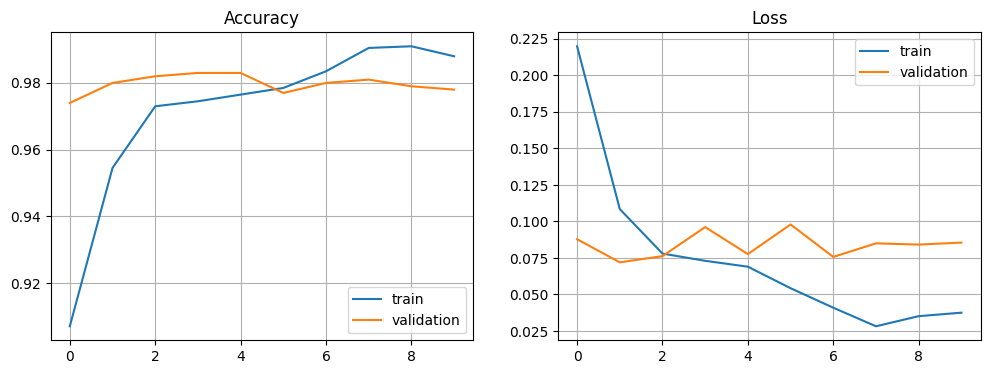

In [22]:
FINE_TUNE_EPOCHS = 10

history_fine_tuning = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    verbose=1,
)

print_best_metrics(history_fine_tuning.history)
plot_results(history_fine_tuning)


## Fine-Tuning Result Interpretation

Fine-tuning increased training accuracy substantially, while validation accuracy improved only slightly compared with the frozen-feature stage. Validation loss also began to rise during the later fine-tuning epochs, indicating mild overfitting. This suggests that the pretrained ImageNet features were already highly effective for the Cats vs Dogs task and that additional fine-tuning provided only limited improvement in generalization.


## Transfer-Learning Takeaways

The workflow separates transfer learning into two stages:

1. **Feature extraction:** freeze the pretrained backbone and train only the new task-specific classifier.
2. **Fine-tuning:** unfreeze selected upper backbone layers and continue training with a smaller learning rate.

This approach reuses general ImageNet representations while allowing higher-level features to adapt to the Cats vs Dogs task.
